# Donut Fined-Tuned Model Test

`naver-clova-ix/donut-base-finetuned-cord-v2` 모델을 사용하여 CORD-v2(영수증 파싱) 태스크를 테스트합니다.

> 🔹 **환경 확인** — Python·PyTorch·CUDA·GPU 사용 가능 여부 점검

In [6]:
import sys, torch
print(f"Python: {sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Python: 3.11.15 (main, Mar 11 2026, 17:11:19) [GCC 14.3.0]
PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GB10


> 🔹 **라이브러리 import** — transformers·datasets·PIL·matplotlib

In [7]:
from transformers import DonutProcessor, VisionEncoderDecoderModel
from transformers.utils import logging as hf_logging
hf_logging.disable_progress_bar()

from datasets import load_dataset
from PIL import Image
import torch, json, re
import matplotlib.pyplot as plt
import matplotlib as mpl

## Base Model vs Fine-tuned Model

### Base Model (`donut-base`)
대량의 문서 이미지로 **일반적인 패턴**을 학습한 모델

모델 페이지: https://huggingface.co/naver-clova-ix/donut-base

- 약 1,100만(11M) 장의 영문 스캔 문서 이미지 (담배 소송 관련 공개 문서 모음).
- 정답 텍스트 라벨이 없으므로, 상용 OCR 엔진으로 pseudo-label(읽기 순서대로의
  텍스트)을 만들어 학습 타깃으로 사용.
- 주로 영어 위주, 실제 노이즈가 많은 스캔 품질을 학습.

#### pseudo-label 이 뭐고, 왜 쓰나? (핵심)

- 지도학습엔 `이미지 → 정답 텍스트` 쌍이 필요한데, 1,100만 장에 사람이 적어둔 정답이 **없음**.
  사람이 일일이 전사하는 건 비용·시간상 불가능.
- 그래서 **상용 OCR 로 텍스트를 자동 추출** → 이 "가짜 정답"을 학습 타깃으로 씀. 이게 **pseudo-label**.
  ("읽기 순서대로" = OCR 이 글자 위치를 기준으로 왼→오, 위→아래 사람이 읽는 순서로 정렬)
- 목표가 "완벽한 정답"이 아니라 **"이미지에서 글자를 읽는 능력"** 학습이라,
  OCR 이 일부 틀려도 대규모 학습으로 충분히 "읽는 눈"을 얻음.

| 단계 | 정답 출처 | 배우는 것 |
|------|-----------|-----------|
| **사전학습** (base) | OCR pseudo-label (가짜 정답) | 글자 읽기 |
| **파인튜닝** (cord-v2) | 사람이 만든 진짜 JSON | 영수증 → JSON |

| 항목 | 내용 |
|------|------|
| 학습 데이터 | IIT-CDIP (1100만 장의 다양한 문서 이미지) |
| 학습 목표 | 이미지에서 텍스트를 읽는 능력 자체를 익힘 |
| 결과 | 문서를 "보고 이해"할 수 있지만 특정 태스크는 모름 |

### Fine-tuned Model (`donut-base-finetuned-cord-v2`)
Huggingface 데이터셋 다운로드 : https://huggingface.co/datasets/naver-clova-ix/cord-v2

Base Model을 출발점으로, **특정 태스크 데이터**로 추가 학습한 모델

| 항목 | 내용 |
|------|------|
| 학습 데이터 | CORD-v2 (영수증 800장 + 정답 JSON) |
| 학습 목표 | 영수증 → `gt_parse` JSON 구조로 변환 |
| 결과 | 영수증 파싱에 특화된 능력 보유 |

사전학습된 donut-base는 위 데이터로 "읽기"만 익힌 상태이며, 실제 활용(영수증 파싱
CORD, 문서 분류 RVL-CDIP, DocVQA 등)에는 각 downstream 데이터로 fine-tuning해서
씁니다.

### 비유

```
Base Model   = 대학 졸업생  (읽기·이해력은 갖춤, 전문 업무는 아직 모름)
Fine-tuning  = 입사 후 실무 교육  (영수증 처리 업무만 집중 훈련)
Fine-tuned   = 영수증 처리 전문 직원  (영수증 → JSON 즉시 변환 가능)
```

### 학습 흐름

```
[Base Model 사전학습]
대용량 문서 → 일반 표현 학습
        ↓
[Fine-tuning]
CORD-v2 영수증 800장 + 정답 JSON → 태스크 특화 학습
        ↓
[Fine-tuned Model]
영수증 이미지 + <s_cord-v2> 태스크 토큰 → JSON 출력
```

> 🔹 **파인튜닝 모델 + 프로세서 로드** — `donut-base-finetuned-cord-v2` (Swin 인코더 + mBART 디코더)

In [8]:
model_name = "naver-clova-ix/donut-base-finetuned-cord-v2"

# DonutProcessor: 이미지 전처리(resize, normalize) + 토크나이저를 하나로 묶은 클래스
processor = DonutProcessor.from_pretrained(model_name, use_fast=False)

# VisionEncoderDecoderModel: Swin Transformer(encoder) + mBART(decoder) 구조
model = VisionEncoderDecoderModel.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()  # 추론 모드: dropout 비활성화, gradient 계산 불필요
print(f"Model loaded on {device}")

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model loaded on cuda


## CORD-v2 Dataset 구조

영수증 이미지 + JSON 어노테이션으로 구성된 문서 파싱 벤치마크 데이터셋

### Splits

| Split      | 샘플 수 |
|------------|--------|
| train      | 800    |
| validation | 100    |
| test       | 100    |

### 컬럼

| 컬럼명          | 타입        | 설명                      |
|----------------|-------------|---------------------------|
| `image`        | PIL Image   | 영수증 이미지              |
| `ground_truth` | JSON string | 레이블 + 메타 정보 전체    |

### `ground_truth` JSON 구조

```
ground_truth
├── gt_parse              ← Donut 학습에 사용하는 핵심 레이블
│   ├── menu []           ← 주문 항목 목록
│   │   ├── nm                메뉴명
│   │   ├── cnt               수량
│   │   ├── price             가격
│   │   ├── unitprice         단가
│   │   ├── itemsubtotal      항목 소계
│   │   ├── num               번호
│   │   ├── discountprice     할인가
│   │   ├── vatyn             부가세 여부
│   │   ├── sub               하위 항목
│   │   └── etc               기타
│   ├── sub_total         ← 소계 영역
│   │   ├── subtotal_price    소계
│   │   ├── discount_price    할인
│   │   ├── service_price     서비스료
│   │   ├── tax_price         세금
│   │   ├── othersvc_price    기타 서비스료
│   │   └── etc               기타
│   ├── total             ← 합계 영역
│   │   ├── total_price       총액
│   │   ├── creditcardprice   카드 결제
│   │   ├── cashprice         현금 결제
│   │   ├── changeprice       거스름돈
│   │   ├── emoneyprice       전자화폐
│   │   ├── menutype_cnt      메뉴 종류 수
│   │   ├── menuqty_cnt       총 수량
│   │   └── total_etc         기타
│   └── void_menu []      ← 취소 항목 (선택적)
├── meta                  ← image_id, image_size, split 등 메타 정보
├── valid_line []         ← 단어별 바운딩 박스 좌표 (OCR 전용, Donut 미사용)
├── roi                   ← 관심 영역 좌표
├── repeating_symbol      ← 반복 기호
└── dontcare []           ← 무시할 영역
```

> Donut은 `gt_parse` 만 사용하며, `valid_line` / `roi` 등은 다른 OCR 모델용 어노테이션입니다.

> 🔹 CORD-v2 테스트 샘플 1장 로드 → 이미지와 정답(`gt_parse`) 확인

Dataset({
    features: ['image', 'ground_truth'],
    num_rows: 1
})
샘플 수: 1, 컬럼 수: 2

=== 이미지 정보 ===
크기: (432, 648)  모드: RGB

=== ground_truth 최상위 키 ===
['gt_parse', 'meta', 'valid_line', 'roi', 'repeating_symbol', 'dontcare']

=== gt_parse 키 ===
['menu', 'sub_total', 'total']

=== gt_parse 내용 ===
{
  "menu": {
    "nm": "-TICKET CP",
    "num": "901016",
    "cnt": "2",
    "price": "60.000",
    "itemsubtotal": "60.000"
  },
  "sub_total": {
    "subtotal_price": "60.000",
    "discount_price": "-60.000",
    "tax_price": "5.455"
  },
  "total": {
    "total_price": "60.000",
    "creditcardprice": "60.000",
    "menuqty_cnt": "2.00"
  }
}


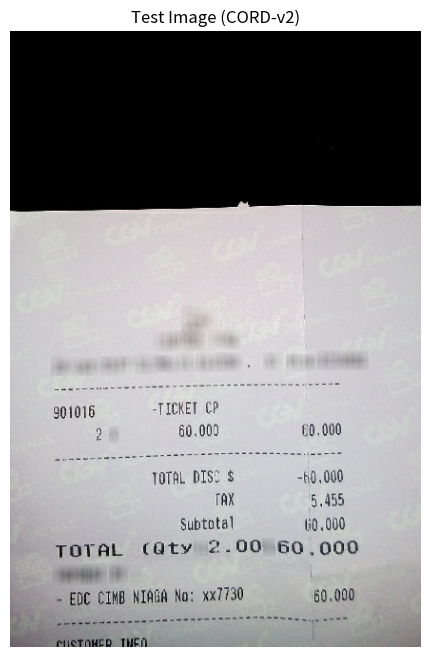

In [9]:
# CORD-v2: 영수증 이미지 + JSON 어노테이션 데이터셋 (donut-base의 학습 도메인)
# test[:1] → 테스트셋 첫 번째 샘플 1장만 로드
dataset = load_dataset("naver-clova-ix/cord-v2", split="test[:1]")
print(dataset)                           # Dataset은 .shape 없음 → print로 확인
print(f"샘플 수: {len(dataset)}, 컬럼 수: {len(dataset.features)}")

image = dataset[0]["image"]
ground_truth = json.loads(dataset[0]["ground_truth"])

# 샘플 구조 출력
print("\n=== 이미지 정보 ===")
print(f"크기: {image.size}  모드: {image.mode}")

print("\n=== ground_truth 최상위 키 ===")
print(list(ground_truth.keys()))

print("\n=== gt_parse 키 ===")
gt = ground_truth["gt_parse"]
print(list(gt.keys()))

print("\n=== gt_parse 내용 ===")
print(json.dumps(gt, indent=2, ensure_ascii=False))

plt.figure(figsize=(6, 8))
plt.imshow(image)
plt.axis("off")
plt.title("Test Image (CORD-v2)")
plt.show()

### 로컬 캐시 위치

`load_dataset` 최초 실행 시 HuggingFace Hub에서 자동 다운로드되며, 이후 호출은 캐시에서 즉시 로드됩니다.

```
~/.cache/huggingface/datasets/naver-clova-ix___cord-v2/
└── default/0.0.0/7f0115a4.../
    ├── cord-v2-train-00000-of-00002.arrow   ← train (절반)
    ├── cord-v2-train-00001-of-00002.arrow   ← train (절반)
    ├── cord-v2-validation.arrow             ← validation
    ├── cord-v2-test.arrow                   ← test
    └── dataset_info.json                    ← 메타 정보
```

| 항목   | 내용                                        |
|--------|---------------------------------------------|
| 총 용량 | 2.2 GB                                     |
| 포맷   | `.arrow` (Apache Arrow — 빠른 컬럼형 포맷)  |

> 🔹 **모델 구조(`config`) 출력** — 인코더/디코더 설정·`max_position_embeddings` 확인

In [10]:
print(model.config)

VisionEncoderDecoderConfig {
  "architectures": [
    "VisionEncoderDecoderModel"
  ],
  "decoder": {
    "_name_or_path": "",
    "activation_dropout": 0.0,
    "activation_function": "gelu",
    "add_cross_attention": true,
    "add_final_layer_norm": true,
    "architectures": null,
    "attention_dropout": 0.0,
    "bos_token_id": 0,
    "chunk_size_feed_forward": 0,
    "classifier_dropout": 0.0,
    "cross_attention_hidden_size": null,
    "d_model": 1024,
    "decoder_attention_heads": 16,
    "decoder_ffn_dim": 4096,
    "decoder_layerdrop": 0.0,
    "decoder_layers": 4,
    "decoder_start_token_id": null,
    "dropout": 0.1,
    "dtype": "float32",
    "encoder_attention_heads": 16,
    "encoder_ffn_dim": 4096,
    "encoder_layerdrop": 0.0,
    "encoder_layers": 12,
    "eos_token_id": 2,
    "finetuning_task": null,
    "id2label": {
      "0": "LABEL_0",
      "1": "LABEL_1"
    },
    "init_std": 0.02,
    "is_decoder": true,
    "is_encoder_decoder": false,
    "label2id":

> 🔹 **특수(구조) 토큰 목록 출력** — `all_special_tokens` (`<s>`/`</s>`/`<s_cord-v2>` 등)

In [11]:
# 등록된 특수 토큰 목록 확인
# <s_cord-v2> ->  태스크 이름 = 학습에 사용한 데이터셋 이름
print(processor.tokenizer.all_special_tokens)

['<s>', '</s>', '<unk>', '<pad>', '<mask>', '<s_cord-v2>']


### 특수 토큰(Special Tokens) 설명

`processor.tokenizer.all_special_tokens` 의 출력입니다.

```
['<s>', '</s>', '<unk>', '<pad>', '<mask>', '<s_cord-v2>']
```

| 토큰 | 이름 | 역할 |
|------|------|------|
| `<s>` | BOS | 시퀀스 시작 (begin of sequence) |
| `</s>` | EOS | 시퀀스 끝 — 생성이 여기서 **멈춤** |
| `<unk>` | UNK | 사전에 없는 미지의 토큰 (생성 시 금지) |
| `<pad>` | PAD | 길이 맞춤용 빈 채움 토큰 (loss 계산에서 무시) |
| `<mask>` | MASK | 마스킹용 (BART 사전학습 잔재, 추론엔 미사용) |
| `<s_cord-v2>` | **태스크 토큰** | "영수증 파싱" 과제 지정 = 디코더 시작 입력 |

#### 핵심

- 앞의 5개(`<s>` ~ `<mask>`)는 **mBART에서 물려받은 표준 토큰**입니다.
- 마지막 `<s_cord-v2>` 하나만 **CORD-v2 fine-tuning 때 추가로 등록**된 토큰입니다.
  이것이 "어떤 태스크인지"를 나타내며 디코더의 첫 입력으로 들어갑니다.
  (도면 프로젝트에서 `<s_drawing>` 을 새로 등록하는 것과 같은 자리)

> 참고: `<s_menu>`, `<s_total>` 같은 **필드 토큰**은 이 목록에 **안 보입니다.**
> 이들은 `additional_special_tokens` 가 아니라 **`add_tokens`(일반 추가 토큰)** 으로 등록돼 있어
> `all_special_tokens` / `additional_special_tokens` 어디에도 나오지 않습니다.
> (그래서 `additional_special_tokens` 에는 `<s_cord-v2>` 만 들어 있습니다.)
> → 필드 토큰은 **`processor.tokenizer.get_added_vocab()`** 으로 꺼냅니다 (아래 셀 참고).

> 🔹 **필드 토큰 출력** — `get_added_vocab()`에서 `<s_menu>`/`<s_total>` 등 CORD 스키마 키 추출

In [12]:
# 필드 토큰 출력
# 주의: <s_menu>, <s_nm>, <s_total> 같은 '필드 토큰'은 all_special_tokens 에 안 보인다.
#       CORD-v2 fine-tuning 때 add_tokens 로 등록된 '추가 토큰'이므로 get_added_vocab() 로 꺼낸다.
added = processor.tokenizer.get_added_vocab()   # 추가된 모든 토큰 {토큰: id}

# 여는(<s_X>)/닫는(</s_X>) 쌍이 모두 있는 것만 = 진짜 필드 토큰.
# (cord-v2 / synthdog / iitcdip 같은 '태스크 토큰'은 닫는 짝이 없어 자동 제외)
fields = sorted(t[3:-1] for t in added
                if t.startswith("<s_") and f"</s_{t[3:-1]}>" in added)

print(f"필드 토큰 {len(fields)}종 (여는/닫는 쌍):")
for f in fields:
    print(f"  <s_{f}> … </s_{f}>")

필드 토큰 27종 (여는/닫는 쌍):
  <s_cashprice> … </s_cashprice>
  <s_changeprice> … </s_changeprice>
  <s_cnt> … </s_cnt>
  <s_creditcardprice> … </s_creditcardprice>
  <s_discount_price> … </s_discount_price>
  <s_discountprice> … </s_discountprice>
  <s_emoneyprice> … </s_emoneyprice>
  <s_etc> … </s_etc>
  <s_itemsubtotal> … </s_itemsubtotal>
  <s_menu> … </s_menu>
  <s_menuqty_cnt> … </s_menuqty_cnt>
  <s_menutype_cnt> … </s_menutype_cnt>
  <s_nm> … </s_nm>
  <s_num> … </s_num>
  <s_othersvc_price> … </s_othersvc_price>
  <s_price> … </s_price>
  <s_service_price> … </s_service_price>
  <s_sub> … </s_sub>
  <s_sub_total> … </s_sub_total>
  <s_subtotal_price> … </s_subtotal_price>
  <s_tax_price> … </s_tax_price>
  <s_total> … </s_total>
  <s_total_etc> … </s_total_etc>
  <s_total_price> … </s_total_price>
  <s_unitprice> … </s_unitprice>
  <s_vatyn> … </s_vatyn>
  <s_void_menu> … </s_void_menu>


> 🔹 **추론** — task 토큰으로 `generate` → 특수토큰 제거 → raw 토큰열(`<s_menu>…`) 생성

In [ ]:
# task_prompt: 모델에게 수행할 태스크를 지정하는 특수 토큰
# <s_cord-v2>는 영수증 파싱 태스크를 의미하며, 디코더의 첫 번째 입력으로 사용됨
task_prompt = "<s_cord-v2>"
decoder_input_ids = processor.tokenizer(
    task_prompt, add_special_tokens=False, return_tensors="pt"
).input_ids.to(device)

# processor: 이미지를 모델 입력 크기(1280×960)로 리사이즈 후 [-1, 1] 범위로 정규화
pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

with torch.no_grad():  # 추론 시 gradient 계산 생략 → 메모리 절약
    outputs = model.generate(
        pixel_values,
        decoder_input_ids=decoder_input_ids,
        max_length=model.decoder.config.max_position_embeddings,  # 최대 시퀀스 길이
        pad_token_id=processor.tokenizer.pad_token_id,
        eos_token_id=processor.tokenizer.eos_token_id,            # EOS 토큰 도달 시 생성 중단
        use_cache=True,                                            # KV-cache로 디코딩 속도 향상
        bad_words_ids=[[processor.tokenizer.unk_token_id]],       # UNK 토큰 생성 금지
        return_dict_in_generate=True,
    )

# 생성된 토큰 ID → 문자열로 디코딩
sequence = processor.batch_decode(outputs.sequences)[0]

# ── 특수 토큰 제거 (token2json 파싱 전 필수) ─────────────────────────────
#   모델 출력 형태:  <s> <s_cord-v2> <s_menu>…</s_menu> … </s>
#     · <s>          = BOS(Begin Of Sequence, 시퀀스 시작 토큰)
#                       — 여기선 decoder_input_ids=task 로 시작해 보통 안 나오지만, 방어적으로 함께 제거
#     · <s_cord-v2>  = task 토큰(과제 지정 + 디코더 시작). '여는 태그'인데 '닫는 짝(</s_cord-v2>)'이 없음
#     · </s>         = EOS(끝),  <pad> = 패딩
#   ★ 왜 떼나: BOS·task 토큰은 '닫는 짝 없는 여는 태그'라, 안 떼면 token2json 의 정규식
#     <s_(...)> 이 이걸 키로 오인 → 닫는 태그를 못 찾아 파싱이 깨짐 → 점수 0.
#     그래서 token2json 호출 '전에' 반드시 제거한다.

# EOS, PAD 제거
sequence = sequence.replace(processor.tokenizer.eos_token, "").replace(
    processor.tokenizer.pad_token, ""
)

# 맨 앞 task 토큰(<s_cord-v2>) 제거 — re.sub 로 '첫 태그 1개'만 떼어냄 (BOS <s> 가 앞에 있어도 첫 태그가 먼저 제거됨)
# 예: "<s_cord-v2><s_menu>…실제내용…" → "<s_menu>…실제내용…"
sequence = re.sub(r"<.*?>", "", sequence, count=1).strip()
print("Raw output:", sequence)

## 추론 (Inference)

### 정규식 패턴 `re.sub(r"<.*?>", "", sequence, count=1)`

Donut 출력의 맨 앞 태스크 토큰 `<s_cord-v2>`를 제거하는 코드입니다.

#### 패턴 각 문자 의미

| 문자 | 의미 |
|------|------|
| `r"..."` | raw string — 백슬래시를 특수문자로 처리하지 않음 |
| `<` | `<` 문자 그대로 매칭 |
| `.` | 어떤 문자든 1개 |
| `*` | 앞 문자(`.`)가 0개 이상 반복 |
| `?` | 최소 매칭 — 가능한 짧게 매칭 |
| `>` | `>` 문자 그대로 매칭 |

#### `*` vs `*?` 차이 (최대 매칭 vs 최소 매칭)

```python
문자열 = "<s_menu><s_nm>치킨</s_nm>"

r"<.*>"   # 최대 매칭 → <s_menu><s_nm>치킨</s_nm> 전체를 하나로 잡음
r"<.*?>"  # 최소 매칭 → <s_menu> 만 잡음 (첫 > 에서 멈춤)
```

#### 실제 동작

```python
re.sub(r"<.*?>", "", "<s_cord-v2><s_menu>치킨</s_menu>", count=1)
# count=1 → 맨 앞 태그 1개만 제거
# → "<s_menu>치킨</s_menu>"
```

> 🔹 **`token2json`** — XML식 토큰열을 JSON(dict)으로 역파싱

In [14]:
def token2json(tokens, is_inner_value=False):
    """XML-like 토큰 시퀀스를 Python dict로 변환
    예: <s_total>12500</s_total> → {"total": "12500"}
    중첩 구조(dict 안의 dict)도 재귀적으로 처리
    """
    output = {}
    while tokens:
        start_token = re.search(r"<s_(.*?)>", tokens)
        if not start_token:
            break
        key = start_token.group(1)
        end_token = re.search(rf"</s_{key}>", tokens)
        value = tokens[start_token.end(): end_token.start() if end_token else len(tokens)]
        value = value.strip()
        if re.search(r"<s_", value):          # 중첩 태그가 있으면 재귀 파싱
            value = token2json(value, is_inner_value=True)
            if value:
                output[key] = value
        else:
            output[key] = value               # 리프 노드: 문자열 값 저장
        tokens = tokens[end_token.end():].strip() if end_token else ""
    return output

result = token2json(sequence)
print("Parsed result:")
print(json.dumps(result, indent=2, ensure_ascii=False))

Parsed result:
{
  "menu": {
    "nm": "- TICKET CP",
    "num": "901016",
    "unitprice": "60.000",
    "cnt": "2",
    "price": "60,000"
  },
  "sub_total": {
    "subtotal_price": "-60.000",
    "tax_price": "5,455"
  },
  "total": {
    "total_price": "60.000",
    "emoneyprice": "60.000",
    "menuqty_cnt": "2.00"
  }
}


### `token2json` 함수

Donut이 출력한 XML 형태의 토큰 시퀀스를 Python `dict`로 변환하는 함수입니다.

#### 입력 / 출력

```
입력 (Raw output 문자열)
<s_menu><s_nm>치킨</s_nm><s_price>12000</s_price></s_menu><s_total><s_total_price>12000</s_total_price></s_total>

출력 (Python dict)
{
  "menu": {
    "nm": "치킨",
    "price": "12000"
  },
  "total": {
    "total_price": "12000"
  }
}
```

#### 동작 흐름

```
1. <s_키> 태그 탐색        re.search(r"<s_(.*?)>", tokens)
        ↓
2. </s_키> 닫힘 태그 탐색  re.search(rf"</s_{key}>", tokens)
        ↓
3. 태그 사이 값 추출
        ↓
4. 값 안에 <s_> 태그가 있으면?
   ├── YES → 재귀 호출 (중첩 dict 생성)
   └── NO  → 문자열 값으로 저장
        ↓
5. 닫힘 태그 이후 문자열로 이동 후 반복
```

#### 재귀 처리 예시

```python
# 중첩 태그 → 재귀적으로 dict 안의 dict 생성
"<s_menu><s_nm>치킨</s_nm></s_menu>"
→ {"menu": {"nm": "치킨"}}   # menu 값 파싱 시 재귀 호출

# 리프 노드 → 문자열로 저장
"<s_nm>치킨</s_nm>"
→ {"nm": "치킨"}
```

> 🔹 **정답(`ground_truth`) 출력** — 모델 예측과 비교용

In [15]:
# 데이터셋에 포함된 정답 레이블과 모델 예측 결과를 비교
print("Ground Truth:")
print(json.dumps(ground_truth, indent=2, ensure_ascii=False))

Ground Truth:
{
  "gt_parse": {
    "menu": {
      "nm": "-TICKET CP",
      "num": "901016",
      "cnt": "2",
      "price": "60.000",
      "itemsubtotal": "60.000"
    },
    "sub_total": {
      "subtotal_price": "60.000",
      "discount_price": "-60.000",
      "tax_price": "5.455"
    },
    "total": {
      "total_price": "60.000",
      "creditcardprice": "60.000",
      "menuqty_cnt": "2.00"
    }
  },
  "meta": {
    "version": "2.0.0",
    "split": "test",
    "image_id": 0,
    "image_size": {
      "width": 432,
      "height": 648
    }
  },
  "valid_line": [
    {
      "words": [
        {
          "quad": {
            "x2": 92,
            "y3": 412,
            "x3": 92,
            "y4": 412,
            "x1": 42,
            "y1": 392,
            "x4": 42,
            "y2": 392
          },
          "is_key": 0,
          "row_id": 2028655,
          "text": "901016"
        }
      ],
      "category": "menu.num",
      "group_id": 11,
      "sub_group_id": 

> 🔹 **시각화** — 입력 이미지 + 파싱 결과를 나란히 표시

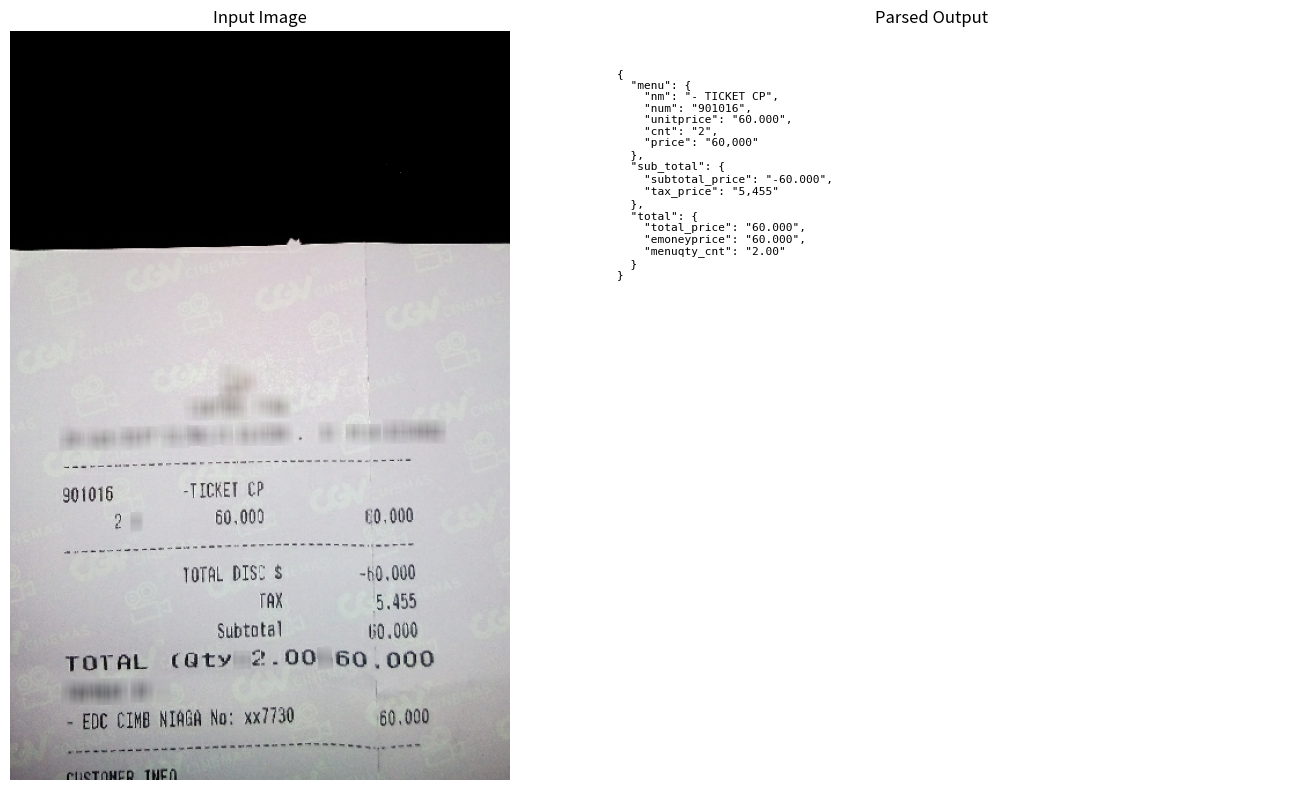

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

axes[0].imshow(image)
axes[0].axis("off")
axes[0].set_title("Input Image")

axes[1].axis("off")
axes[1].set_title("Parsed Output")
axes[1].text(
    0.05, 0.95,
    json.dumps(result, indent=2, ensure_ascii=False),
    transform=axes[1].transAxes,
    fontsize=8,
    verticalalignment="top",
    fontfamily="monospace"
)

plt.tight_layout()
plt.show()